# Análisis de ventas y clientes – Velmora

## Contexto

Velmora es un e-commerce enfocado en productos de hogar y skincare.  
El objetivo de este análisis es entender el comportamiento de ventas y clientes para detectar oportunidades de crecimiento.

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# cargar datos
orders = pd.read_csv('/kaggle/input/datasets/lesrodpob/velmora-dataset/orders.csv', encoding='ISO-8859-1')
customers = pd.read_csv('/kaggle/input/datasets/lesrodpob/velmora-dataset/customers.csv', encoding='ISO-8859-1')
products = pd.read_csv('/kaggle/input/datasets/lesrodpob/velmora-dataset/products.csv', encoding='ISO-8859-1')

# limpieza
orders['date'] = pd.to_datetime(orders['date'])

# merge
df = orders.merge(customers, on='customer_id')
df = df.merge(products, on='product_id')

# métrica clave
df['total'] = df['quantity'] * df['price']

df.head()

,order_id,date,customer_id,product_id,quantity,price,city,age,gender,product_name,category,total
0,1,2024-01-05,101,2001,2,15000,Santiago,28,F,Vela Aromática,Home,30000
1,2,2024-01-10,102,2002,1,22000,Valparaiso,35,M,Difusor,Home,22000
2,3,2024-01-15,103,2003,3,8000,Viña del Mar,30,F,Jabón Natural,Skincare,24000
3,4,2024-02-01,101,2002,1,22000,Santiago,28,F,Difusor,Home,22000
4,5,2024-02-10,104,2001,2,15000,Santiago,40,M,Vela Aromática,Home,30000


## Ventas totales

In [38]:
df['total'].sum()

np.int64(294000)

### Insight
El negocio presenta un volumen total de ventas positivo considerando el tamaño del dataset.

### Interpretación
Esto indica que Velmora ya tiene tracción inicial en el mercado, aunque aún en una etapa temprana de crecimiento.

### Recomendación
Focalizar esfuerzos en escalar el volumen de ventas mediante adquisición de nuevos clientes y aumento del ticket promedio.

# Ventas por mes

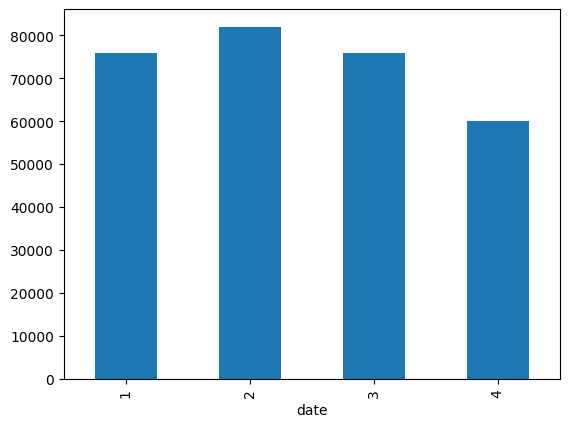

In [39]:
ventas_mes = df.groupby(df['date'].dt.month)['total'].sum()
ventas_mes.plot(kind='bar')
plt.show()

### Insight
Se observa un crecimiento progresivo en las ventas desde enero hasta abril.

### Interpretación
Esto sugiere una tendencia positiva del negocio, posiblemente impulsada por mayor visibilidad de la marca o aumento en la base de clientes.

### Recomendación
Analizar qué estrategias se implementaron en los meses de mayor crecimiento para replicarlas y sostener la tendencia.

# Productos más vendidos

In [40]:
df.groupby('product_name')['total'].sum().sort_values(ascending=False)

product_name
Crema Facial      90000
Vela Aromática    75000
Set Regalo        45000
Difusor           44000
Jabón Natural     40000
Name: total, dtype: int64

### Insight
Los productos como Vela Aromática y Difusor concentran la mayor parte de los ingresos.

### Interpretación
Estos productos funcionan como el núcleo del negocio, con alta demanda y rotación.

### Recomendación
Asegurar disponibilidad de stock y utilizarlos como productos gancho en campañas de marketing.

## Ventas por categoría

In [49]:
ventas_categoria = df.groupby('category')['total'].sum().sort_values(ascending=False)
ventas_categoria

category
Skincare    130000
Home        119000
Gift         45000
Name: total, dtype: int64

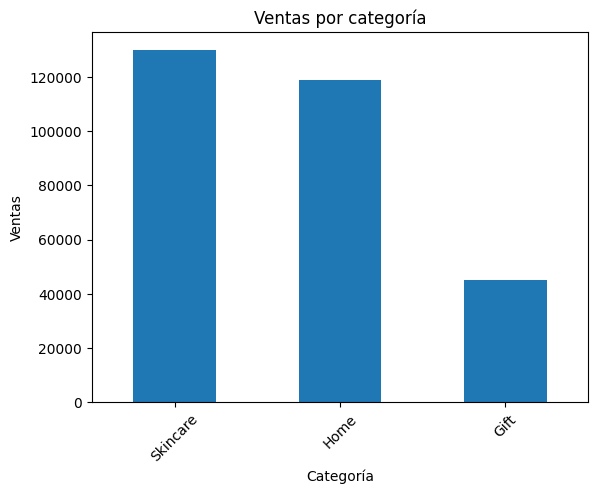

In [47]:
ventas_categoria.plot(kind='bar')
plt.title('Ventas por categoría')
plt.xlabel('Categoría')
plt.ylabel('Ventas')
plt.xticks(rotation=45)
plt.show()

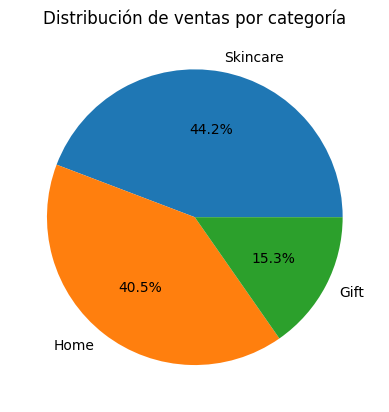

In [50]:
ventas_categoria.plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribución de ventas por categoría')
plt.ylabel('')
plt.show()


### Insight
La categoría Home lidera en generación de ingresos, seguida por Skincare y Gift con menor participación.

### Interpretación
Existe una clara preferencia de los clientes por productos de ambientación del hogar.

### Recomendación
Expandir la oferta en la categoría Home y evaluar estrategias para potenciar categorías con menor rendimiento.

## Cantidad de productos vendidos por categoría

In [51]:
cantidad_categoria = df.groupby('category')['quantity'].sum().sort_values(ascending=False)

cantidad_categoria

category
Skincare    8
Home        7
Gift        1
Name: quantity, dtype: int64

## Precio promedio por categoría

In [52]:
precio_promedio_categoria = df.groupby('category')['price'].mean()

precio_promedio_categoria

category
Gift        45000.0
Home        17800.0
Skincare    19000.0
Name: price, dtype: float64

## Clientes únicos

### Insight
El número de clientes únicos es relativamente bajo en comparación con el volumen de ventas.

### Interpretación
Esto sugiere cierta dependencia en un grupo reducido de clientes, algunos de los cuales realizan múltiples compras.

### Recomendación
Implementar estrategias de adquisición de nuevos clientes para reducir el riesgo de dependencia.

In [41]:
df['customer_id'].nunique()

7

## Clientes recurrentes

### Insight
Se identifican clientes que han realizado más de una compra dentro del período analizado.

### Interpretación
Esto indica un nivel inicial de fidelización, lo cual es positivo para la estabilidad del negocio.

### Recomendación
Fortalecer la retención mediante programas de fidelización, descuentos o beneficios exclusivos.

## Ticket promedio

### Insight
El ticket promedio se mantiene en un rango medio, lo que sugiere compras de bajo a moderado valor.

### Interpretación
Los clientes tienden a comprar pocos productos por transacción.

### Recomendación
Incentivar compras de mayor valor mediante promociones como descuentos por volumen o envío gratuito sobre cierto monto.

In [42]:
df['total'].mean()

np.float64(29400.0)

## Productos con bajo rendimiento

### Insight
Algunos productos presentan baja participación en ventas en comparación con los más vendidos.

### Interpretación
Esto puede deberse a menor demanda, falta de visibilidad o menor competitividad.

### Recomendación
Evaluar si estos productos requieren promoción adicional o si es conveniente reemplazarlos.

## Conclusión

El análisis muestra que Velmora presenta una tendencia de crecimiento sostenida, impulsada principalmente por la categoría Home y productos clave como velas aromáticas y difusores.

Sin embargo, se observa una concentración en pocos clientes y productos, lo que representa una oportunidad para diversificar tanto la base de clientes como la oferta.

Para sostener el crecimiento, se recomienda potenciar los productos más vendidos, implementar estrategias de fidelización y optimizar el mix de productos.